# Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering

**Machine Learning Laboratory — Experiment 8**

Dataset: UCI Human Activity Recognition Using Smartphones (HAR)


## Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
)
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "UCI HAR Dataset"

## Load Dataset

Loads the official UCI HAR `train`/`test` splits (561 features, 6 activities, 30 subjects) and
merges them back into a single dataset, since clustering is unsupervised and does not need the
original train/test split.


In [2]:
# ---------------- Load data ----------------
features = pd.read_csv(f"{DATA_DIR}/features.txt", sep=r"\s+", header=None, names=["idx", "name"])
feature_names = features["name"].tolist()
# de-duplicate feature names (many raw UCI HAR names repeat)
seen = {}
unique_names = []
for n in feature_names:
    if n in seen:
        seen[n] += 1
        unique_names.append(f"{n}_{seen[n]}")
    else:
        seen[n] = 0
        unique_names.append(n)

X_train = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None, names=unique_names)
X_test = pd.read_csv(f"{DATA_DIR}/test/X_test.txt", sep=r"\s+", header=None, names=unique_names)
y_train = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", header=None, names=["activity_id"])
y_test = pd.read_csv(f"{DATA_DIR}/test/y_test.txt", header=None, names=["activity_id"])

activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None,
                               names=["id", "activity"])
label_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)
y_names = y["activity_id"].map(label_map)

print("Full dataset shape:", X.shape)
print("Missing values:", X.isna().sum().sum())
print("\nActivity distribution:")
print(y_names.value_counts())


Full dataset shape: (10299, 561)
Missing values: 0

Activity distribution:
activity_id
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


## Stratified Subsampling

10,299 points is a lot to run DBSCAN, Agglomerative Clustering, and t-SNE on comfortably, so a
stratified 2000-point subsample (proportional per activity) is taken for the actual clustering
and visualization, so every algorithm sees the same data and the comparison stays fair.


In [3]:
# For tractable clustering + visualization on a laptop-class run, subsample
# while preserving activity proportions.
SAMPLE_SIZE = 2000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = (
    y_names.to_frame("activity")
    .assign(orig_idx=np.arange(len(y_names)))
    .groupby("activity", group_keys=False)
    .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(y_names), random_state=RANDOM_STATE))["orig_idx"]
    .values
)
X_s = X.iloc[sample_idx].reset_index(drop=True)
y_s = y_names.iloc[sample_idx].reset_index(drop=True)

print("\nSubsampled shape used for clustering:", X_s.shape)
print(y_s.value_counts())



Subsampled shape used for clustering: (2000, 561)
activity_id
LAYING                378
STANDING              370
SITTING               345
WALKING               334
WALKING_UPSTAIRS      300
WALKING_DOWNSTAIRS    273
Name: count, dtype: int64


C:\Users\farih\AppData\Local\Temp\ipykernel_44480\625038999.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(y_names), random_state=RANDOM_STATE))["orig_idx"]


## Preprocessing — Feature Scaling

All 561 features are standardized with `StandardScaler`, since clustering algorithms are
distance-based.


In [4]:
# ---------------- Preprocess ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_s)


## Dimensionality Reduction

A full PCA is fit to determine how many components are needed for 90% variance. A 2-component
PCA and a 2D t-SNE embedding are computed purely for visualization, while a 30-component PCA is
used as the working feature space for all three clustering algorithms, to keep distances
meaningful and DBSCAN/Hierarchical Clustering tractable.


In [5]:
# ---------------- Dimensionality reduction for visualization ----------------
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_for_90 = np.argmax(cum_var >= 0.90) + 1
print(f"\nComponents needed for >=90% variance: {n_for_90}")
print(f"Variance captured by first 2 PCs: {cum_var[1]*100:.2f}%")

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
tsne_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca").fit_transform(X_scaled)

# Also reduce to a handful of PCA components for clustering itself, which
# keeps distances meaningful and DBSCAN/Agglomerative tractable.
N_COMPONENTS_CLUSTERING = 30
pca_cluster = PCA(n_components=N_COMPONENTS_CLUSTERING, random_state=RANDOM_STATE)
X_pca = pca_cluster.fit_transform(X_scaled)
print(f"Variance captured by {N_COMPONENTS_CLUSTERING} PCs used for clustering: "
      f"{np.sum(pca_cluster.explained_variance_ratio_)*100:.2f}%")

y_true = y_s.values

# ==================================================================
# MODEL A: K-MEANS + ELBOW METHOD



Components needed for >=90% variance: 62
Variance captured by first 2 PCs: 57.35%
Variance captured by 30 PCs used for clustering: 81.89%


## Model A: K-Means Clustering and the Elbow Method

K-Means is run for k = 2 to 8, recording WCSS (inertia) and silhouette score at each k.


In [6]:
# ==================================================================
print("\n" + "=" * 60)
print("K-MEANS: ELBOW METHOD")
print("=" * 60)

k_range = range(2, 9)
wcss = []
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_pca, labels)
    sil_scores.append(sil)
    print(f"k={k}: WCSS={km.inertia_:.1f}  Silhouette={sil:.4f}")



K-MEANS: ELBOW METHOD
k=2: WCSS=433577.6  Silhouette=0.4775
k=3: WCSS=359760.2  Silhouette=0.4070
k=4: WCSS=332567.7  Silhouette=0.2174
k=5: WCSS=305593.0  Silhouette=0.1940
k=6: WCSS=291478.2  Silhouette=0.1835
k=7: WCSS=280425.3  Silhouette=0.1602
k=8: WCSS=270008.5  Silhouette=0.1573


### Elbow Curve and Silhouette Score vs k

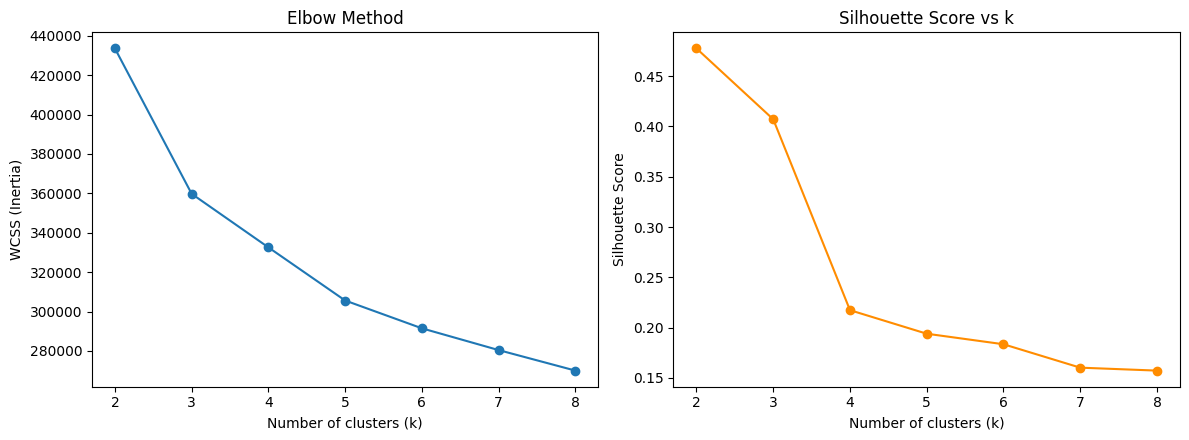

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), wcss, marker='o')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")
axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
plt.tight_layout()
#plt.savefig("elbow_silhouette.png", dpi=150)
plt.show()


### Final K-Means Model

k = 6 is chosen for the main analysis to match the 6 known activities (even though silhouette
alone favours k = 2), so that K-Means, DBSCAN, and Hierarchical Clustering are all judged on the
same basis.


In [8]:
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
CHOSEN_K = 6  # matches the 6 known activities, for comparability with ground truth
print(f"\nk with best silhouette score: {best_k_sil}")
print(f"Chosen k for main analysis (matches 6 known activities): {CHOSEN_K}")

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)

# ==================================================================
# MODEL B: DBSCAN



k with best silhouette score: 2
Chosen k for main analysis (matches 6 known activities): 6


## Model B: DBSCAN

`minPts` is fixed at 60 (twice the 30-dimensional PCA space, a common rule of thumb). A
k-distance plot is used to guide the choice of `eps`.



DBSCAN


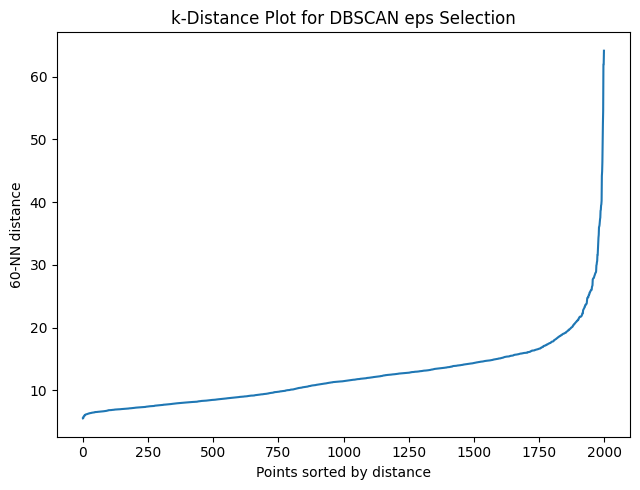

In [9]:
# ==================================================================
print("\n" + "=" * 60)
print("DBSCAN")
print("=" * 60)

# k-distance plot to help pick eps (k = minPts)
minPts = 2 * X_pca.shape[1]
neigh = NearestNeighbors(n_neighbors=minPts)
neigh.fit(X_pca)
distances, _ = neigh.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6.5, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{minPts}-NN distance")
plt.title("k-Distance Plot for DBSCAN eps Selection")
plt.tight_layout()
#plt.savefig("dbscan_kdistance.png", dpi=150)
plt.show()


### Sweeping eps

In [10]:
eps_candidates = [8, 10, 12, 14, 16, 18, 20]
print(f"minPts fixed at {minPts} (2 x n_components)")
dbscan_results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=minPts)
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_pca[mask], labels[mask]) if mask.sum() > 1 else float("nan")
    else:
        sil = float("nan")
    dbscan_results.append((eps, n_clusters, n_noise, sil))
    print(f"eps={eps}: clusters={n_clusters}  noise points={n_noise}  silhouette(non-noise)={sil}")


minPts fixed at 60 (2 x n_components)
eps=8: clusters=1  noise points=1220  silhouette(non-noise)=nan
eps=10: clusters=1  noise points=996  silhouette(non-noise)=nan
eps=12: clusters=2  noise points=483  silhouette(non-noise)=0.5011275946790192
eps=14: clusters=1  noise points=219  silhouette(non-noise)=nan
eps=16: clusters=1  noise points=108  silhouette(non-noise)=nan
eps=18: clusters=1  noise points=70  silhouette(non-noise)=nan
eps=20: clusters=1  noise points=37  silhouette(non-noise)=nan


### Final DBSCAN Model

In [11]:
# pick the eps giving a reasonable number of clusters (2-8) and lowest noise fraction among those
valid = [r for r in dbscan_results if 2 <= r[1] <= 8]
best_eps = min(valid, key=lambda r: r[2])[0] if valid else eps_candidates[len(eps_candidates)//2]
print(f"\nChosen eps: {best_eps}")

dbscan_final = DBSCAN(eps=best_eps, min_samples=minPts)
dbscan_labels = dbscan_final.fit_predict(X_pca)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = int(np.sum(dbscan_labels == -1))
print(f"Final DBSCAN: {n_clusters_db} clusters, {n_noise_db} noise points "
      f"({n_noise_db/len(dbscan_labels)*100:.1f}% of data)")

# ==================================================================
# MODEL C: HIERARCHICAL AGGLOMERATIVE CLUSTERING



Chosen eps: 12
Final DBSCAN: 2 clusters, 483 noise points (24.1% of data)


## Model C: Hierarchical Agglomerative Clustering

Four linkage methods (single, complete, average, ward) are compared at k = 6 using silhouette
score and the Davies-Bouldin index.


In [12]:
# ==================================================================
print("\n" + "=" * 60)
print("HIERARCHICAL AGGLOMERATIVE CLUSTERING")
print("=" * 60)

linkage_methods = ["single", "complete", "average", "ward"]
hac_scores = {}
for method in linkage_methods:
    hac = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage=method)
    labels = hac.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    db_idx = davies_bouldin_score(X_pca, labels)
    hac_scores[method] = (sil, db_idx, labels)
    print(f"linkage={method}: Silhouette={sil:.4f}  Davies-Bouldin={db_idx:.4f}")

best_linkage = max(hac_scores, key=lambda m: hac_scores[m][0])
print(f"\nBest linkage by silhouette: {best_linkage}")
# Ward is used for the main downstream comparison/visuals, as instructed,
# even though single/average can post a higher silhouette here purely from
# chaining a few outliers off one dominant blob (see Observations).
hac_labels = hac_scores["ward"][2]



HIERARCHICAL AGGLOMERATIVE CLUSTERING
linkage=single: Silhouette=0.5590  Davies-Bouldin=0.4092
linkage=complete: Silhouette=0.4458  Davies-Bouldin=1.0389
linkage=average: Silhouette=0.4625  Davies-Bouldin=0.9031
linkage=ward: Silhouette=0.1663  Davies-Bouldin=1.8512

Best linkage by silhouette: single


### Dendrogram (Ward Linkage)

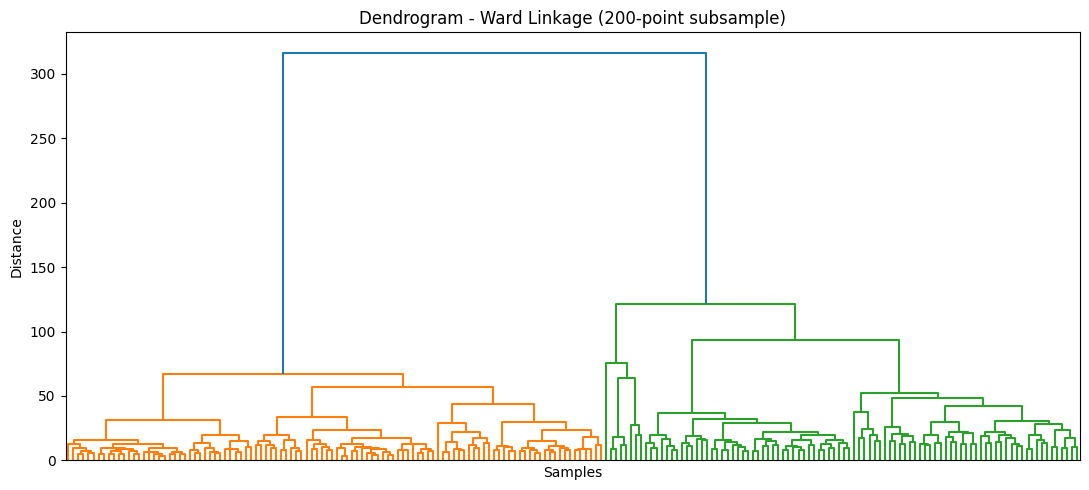

In [13]:
# Dendrogram (Ward linkage, on a further subsample of 200 points for readability)
dendro_idx = rng.choice(len(X_pca), size=min(200, len(X_pca)), replace=False)
Z = linkage(X_pca[dendro_idx], method="ward")
plt.figure(figsize=(11, 5))
dendrogram(Z, no_labels=True)
plt.title("Dendrogram - Ward Linkage (200-point subsample)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
#plt.savefig("dendrogram_ward.png", dpi=150)
plt.show()

# ==================================================================
# EVALUATION METRICS TABLE


## Evaluation Metrics

Internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external metrics against the
true activity labels (ARI, NMI) are computed for all three final models.


In [14]:
# ==================================================================
print("\n" + "=" * 100)
print("EVALUATION METRICS SUMMARY")
print("=" * 100)


def safe_metrics(labels, name):
    mask = labels != -1 if -1 in labels else np.ones(len(labels), dtype=bool)
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X_pca[mask], labels[mask])
        db = davies_bouldin_score(X_pca[mask], labels[mask])
        ch = calinski_harabasz_score(X_pca[mask], labels[mask])
    else:
        sil, db, ch = float("nan"), float("nan"), float("nan")
    ari = adjusted_rand_score(y_true[mask], labels[mask])
    nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
    print(f"{name}: Silhouette={sil:.4f}  DB={db:.4f}  CH={ch:.1f}  ARI={ari:.4f}  NMI={nmi:.4f}")
    return dict(Model=name, Silhouette=sil, DaviesBouldin=db, CalinskiHarabasz=ch, ARI=ari, NMI=nmi)



EVALUATION METRICS SUMMARY


In [15]:
results = [
    safe_metrics(kmeans_labels, f"K-Means (k={CHOSEN_K})"),
    safe_metrics(dbscan_labels, f"DBSCAN (eps={best_eps})"),
    safe_metrics(hac_labels, "Hierarchical (ward)"),
]
results_df = pd.DataFrame(results)
print("\n", results_df.round(4).to_string(index=False))

# ==================================================================
# VISUALIZATION: PCA/t-SNE scatter plots colored by cluster vs true label


K-Means (k=6): Silhouette=0.1835  DB=1.7524  CH=858.3  ARI=0.4178  NMI=0.5629
DBSCAN (eps=12): Silhouette=0.5011  DB=0.8295  CH=1810.5  ARI=0.3022  NMI=0.5321
Hierarchical (ward): Silhouette=0.1663  DB=1.8512  CH=794.6  ARI=0.3541  NMI=0.5345

               Model  Silhouette  DaviesBouldin  CalinskiHarabasz    ARI    NMI
      K-Means (k=6)      0.1835         1.7524          858.3120 0.4178 0.5629
    DBSCAN (eps=12)      0.5011         0.8295         1810.4655 0.3022 0.5321
Hierarchical (ward)      0.1663         1.8512          794.5646 0.3541 0.5345


## Visualization: Cluster Assignments (PCA / t-SNE)

Each algorithm's cluster assignment is visualized in both PCA-2D and t-SNE-2D space.


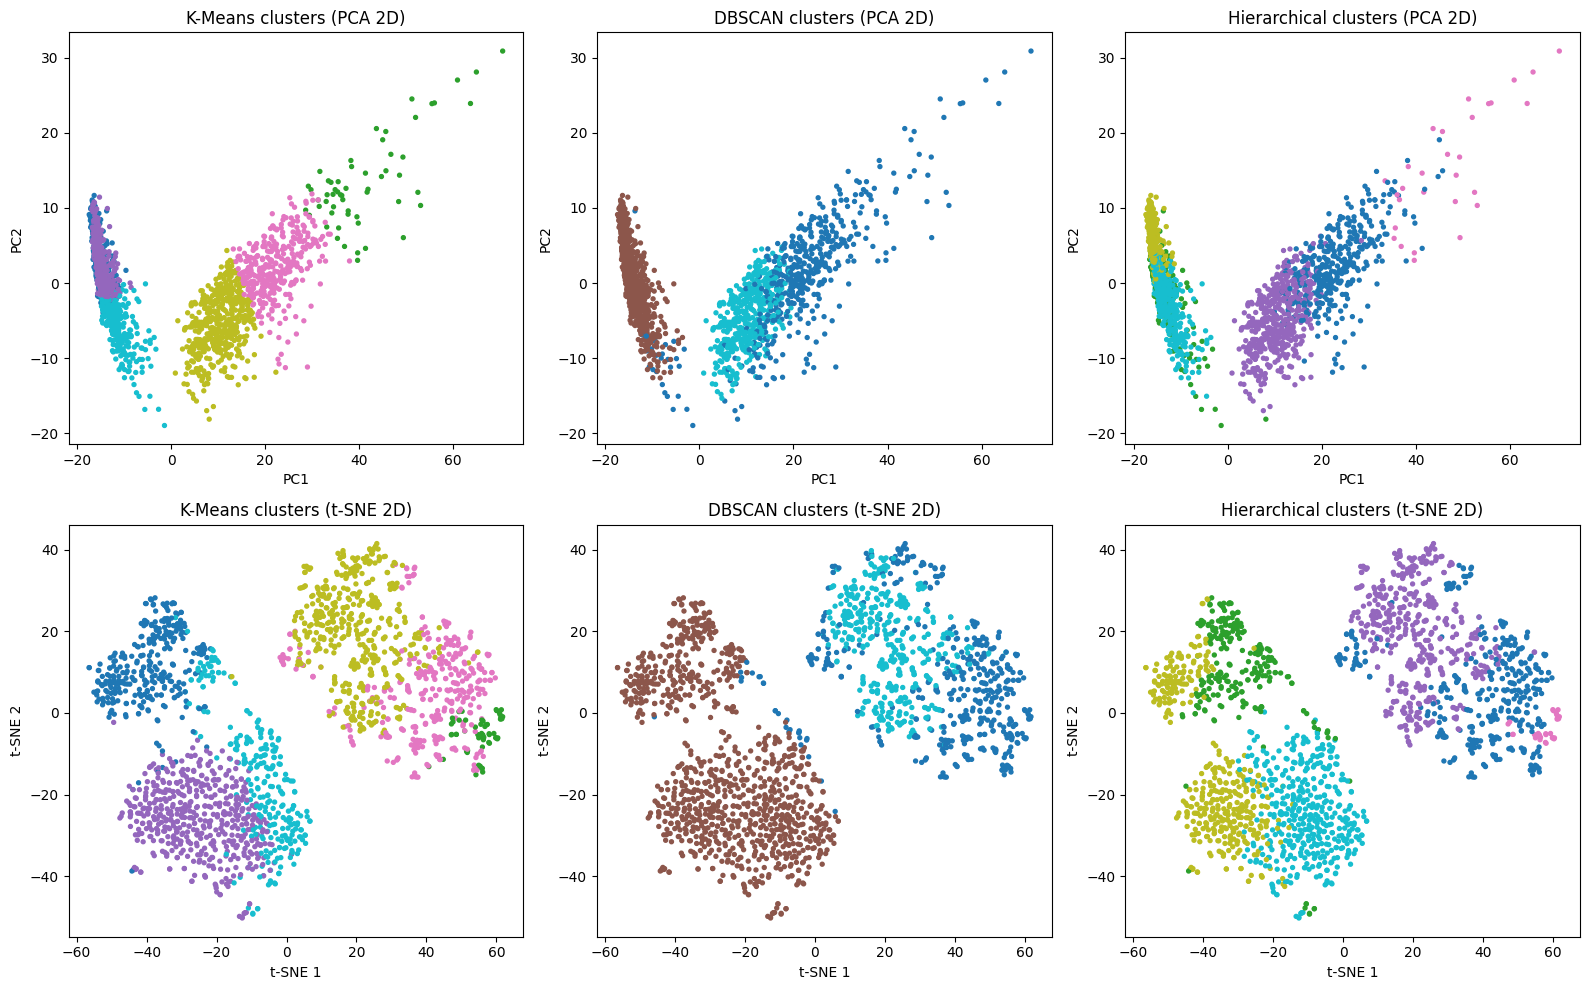

In [16]:
# ==================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cluster_sets = [("K-Means", kmeans_labels), ("DBSCAN", dbscan_labels), ("Hierarchical", hac_labels)]

for i, (name, labels) in enumerate(cluster_sets):
    sc = axes[0, i].scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, cmap="tab10", s=8)
    axes[0, i].set_title(f"{name} clusters (PCA 2D)")
    axes[0, i].set_xlabel("PC1")
    axes[0, i].set_ylabel("PC2")

    sc2 = axes[1, i].scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=labels, cmap="tab10", s=8)
    axes[1, i].set_title(f"{name} clusters (t-SNE 2D)")
    axes[1, i].set_xlabel("t-SNE 1")
    axes[1, i].set_ylabel("t-SNE 2")

plt.tight_layout()
#plt.savefig("cluster_scatter_pca_tsne.png", dpi=150)
plt.show()


### Ground Truth Activity Labels (for reference)

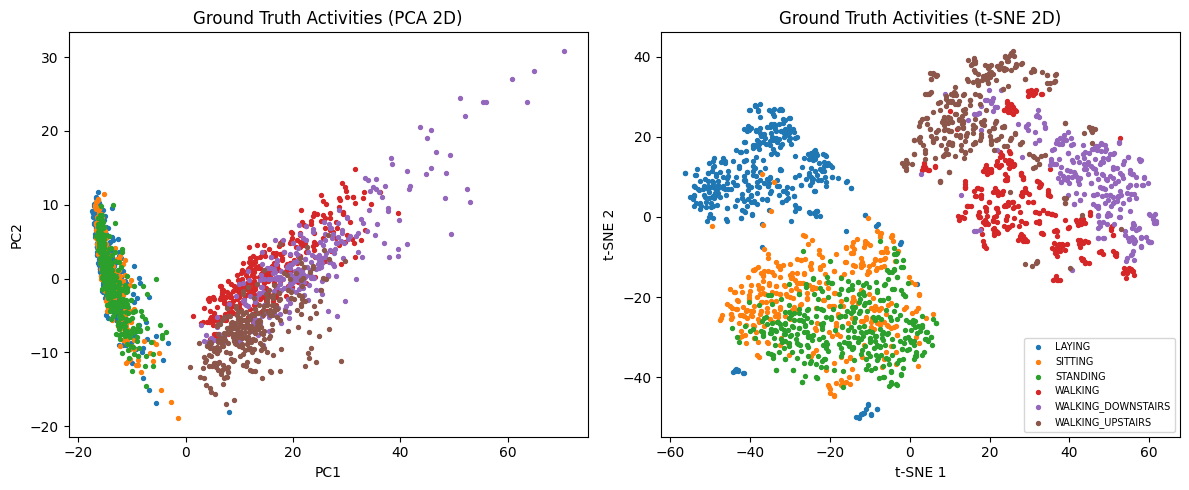

In [17]:
# Ground truth activity plot for reference
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
activities_sorted = sorted(y_s.unique())
cmap = plt.get_cmap("tab10")
for i, act in enumerate(activities_sorted):
    mask = (y_s.values == act)
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=8, color=cmap(i), label=act)
    axes[1].scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], s=8, color=cmap(i), label=act)
axes[0].set_title("Ground Truth Activities (PCA 2D)")
axes[1].set_title("Ground Truth Activities (t-SNE 2D)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[1].legend(fontsize=7, loc="best")
plt.tight_layout()
#plt.savefig("ground_truth_scatter.png", dpi=150)
plt.show()

# ==================================================================
# BAR PLOT OF METRICS ACROSS ALGORITHMS


### Evaluation Metrics — Bar Chart Comparison

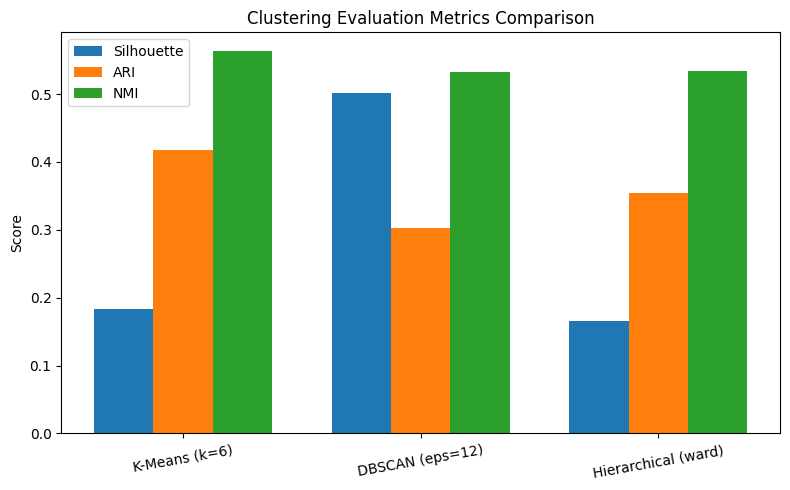

In [18]:
# ==================================================================
metrics_to_plot = ["Silhouette", "ARI", "NMI"]
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.25
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[m], width, label=m)
ax.set_xticks(x + width)
ax.set_xticklabels(results_df["Model"], rotation=10)
ax.set_ylabel("Score")
ax.set_title("Clustering Evaluation Metrics Comparison")
ax.legend()
plt.tight_layout()
#plt.savefig("metrics_barplot.png", dpi=150)
plt.show()

# ==================================================================
# CONFUSION MATRIX: K-Means clusters vs true activities (best mapping)


## K-Means Clusters vs True Activity Labels

A cross-tabulation of the K-Means (k=6) cluster assignments against the true activity labels,
to see exactly which activities get confused with each other.



K-Means cluster vs activity cross-tab:
 activity_id  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
Cluster                                                               
0               305       13         0        0                   0   
1                 0        0         0       12                  45   
2                16      244       249        0                   0   
3                 0        0         0      140                 162   
4                 1        0         0      182                  66   
5                56       88       121        0                   0   

activity_id  WALKING_UPSTAIRS  
Cluster                        
0                           0  
1                           0  
2                           0  
3                          55  
4                         245  
5                           0  


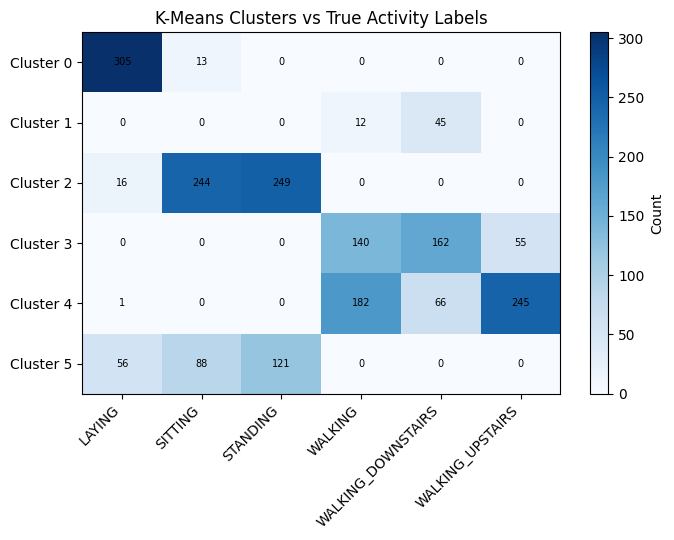


All plots saved.


In [19]:
# ==================================================================
ct = pd.crosstab(pd.Series(kmeans_labels, name="Cluster"), y_s, )
print("\nK-Means cluster vs activity cross-tab:\n", ct)

plt.figure(figsize=(7, 5.5))
plt.imshow(ct, cmap="Blues", aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.yticks(range(len(ct.index)), [f"Cluster {i}" for i in ct.index])
plt.title("K-Means Clusters vs True Activity Labels")
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        plt.text(j, i, ct.values[i, j], ha="center", va="center", fontsize=7)
plt.tight_layout()
#plt.savefig("kmeans_vs_truth_confusion.png", dpi=150)
plt.show()

print("\nAll plots saved.")


## Conclusion

Across K-Means, DBSCAN, and Hierarchical (Ward) clustering on the HAR dataset, K-Means at k=6
gave the most useful match to the real six activities (ARI 0.418, NMI 0.563), mainly by being
willing to accept a lower silhouette score in exchange for actually splitting the data six ways.
DBSCAN is genuinely good at finding the coarsest possible structure (moving vs. stationary) and
flagging outliers, but it isn't well suited to recovering finer-grained classes on this dataset.
Ward's linkage HAC lands in between the two, doing reasonably on external metrics without either
of K-Means' flexibility or DBSCAN's noise handling. If the actual goal is to recover
activity-level clusters, K-Means with a task-informed choice of k (rather than the value
silhouette alone would suggest) is the more practical choice here.
